In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join("../.."))
print(module_path)
if module_path not in sys.path:
    sys.path.append(module_path)
# Import packages that will be used
import c2qa
import custom_gates
import numpy as np
import matplotlib.pyplot as plt
from qiskit import ClassicalRegister, visualization, AncillaRegister,QuantumRegister
from qiskit_aer.noise import NoiseModel, amplitude_damping_error
from qiskit.quantum_info import state_fidelity, Statevector
from qiskit.quantum_info.operators import Operator
from qiskit.quantum_info.operators.predicates import is_unitary_matrix
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import UnitaryGate
from qiskit.circuit.library.standard_gates import HGate
from math import pi, ceil
import scipy
from c2qa.operators import CVOperators
from c2qa.qumoderegister import QumodeRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from c2qa.parameterized_unitary_gate import ParameterizedUnitaryGate
from qutip import *
from scipy.special import eval_hermite, factorial

/Users/shubdeepmohapatra


In [2]:
def qproj00():
    return basis(2, 0).proj()


def qproj11():
    return basis(2, 1).proj()


def qproj01():
    op = np.array([[0, 1], [0, 0]])
    return Qobj(op)


def qproj10():
    op = np.array([[0, 0], [1, 0]])
    return Qobj(op)

def hadamard():
    op = np.array([[1, 1], [1, -1]]) / np.sqrt(2)
    return Qobj(op)

In [3]:
def plot_wigner(state, x_range=5, y_range=5, resolution=200):

    # Define phase-space grid
    x = np.linspace(-x_range, x_range, resolution)
    y = np.linspace(-y_range, y_range, resolution)
    X, Y = np.meshgrid(x, y)

    # Compute the Wigner function
    W = wigner(state, x, y)

    # Plot the Wigner function
    plt.figure(figsize=(6, 5))
    plt.contourf(X, Y, W, 100, cmap="RdBu_r")  
    plt.colorbar(label="Wigner function")
    plt.xlabel("q (position quadrature)")
    plt.ylabel("p (momentum quadrature)")
    plt.title("Wigner Distribution")
    plt.grid(True)
    plt.show()

In [5]:
def position_state(x0, N, hbar=1.0):
    coeffs = []
    for n in range(N):
        Hn = eval_hermite(n, x0 / np.sqrt(hbar))
        coef = (1.0 / np.pi**0.25) * (1.0 / np.sqrt(2**n * factorial(n))) * Hn * np.exp(-x0**2 / (2 * hbar))
        coeffs.append(coef)
    state = Qobj(coeffs, dims=[[N], [1]])
    return state.unit()

## Elementary Operations

In [4]:
def Q_displacement_plus1(cutoff):
    return (-1j*momentum(cutoff)).expm()
def Q_displacement_minus1(cutoff):
    return (1j*momentum(cutoff)).expm()
def bosonic_sum(cutoff1,cutoff2):
    return (-1j*tensor(position(cutoff1),momentum(cutoff2))).expm()
def single_mode_squeeze(cutoff,squeeze_param):
    return (1j*squeeze_param*(position(cutoff)*momentum(cutoff) + momentum(cutoff)*position(cutoff))/2).expm()
def Q_control_plus1(cutoff):
    return tensor(qproj00(),qeye(cutoff)) + tensor(qproj11(),(-1j*momentum(cutoff)).expm())
def Q_control_minus1(cutoff):
    return tensor(qproj00(),qeye(cutoff)) + tensor(qproj11(),(1j*momentum(cutoff)).expm())
def P_displacement_pi(cutoff,sign):
    return tensor(qproj00(),qeye(cutoff)) + tensor(qproj11(),(1j*np.pi*sign*position(cutoff)).expm())
def rotation_control(cutoff,sign):
    return tensor(qproj00(),qeye(cutoff)) + tensor(qproj11(),(1j*np.pi/2*sign*num(cutoff)).expm())


## Test Elementary Operations

In [7]:
N = 50
q = position(N)

## Q displacement by 1

# system1 = basis(N,0)
# system1_after = Q_displacement_plus1(N) * system1

# print(expect(q, system1))
# print(expect(q, system1_after))

## bosonic sum

# system1 = basis(N,0)
# system2 = displace(N,2/np.sqrt(2)) * basis(N,0)
# print("***Initial State***")
# print(expect(q, system1))
# print(expect(q, system2))
# sum_test = tensor(system2,system1)
# sum_test_after = bosonic_sum(N,N)*sum_test

# system1_after = ptrace(sum_test_after, 1)  # Partial trace over subsystem 2
# print("***Final State***")
# print(expect(q, system1_after))

# system2_after = ptrace(sum_test_after, 0)  # Partial trace over subsystem 1
# print(expect(q, system2_after))

## Single mode squeezing
# system1 = basis(N,0)
# system1_after = single_mode_squeeze(N,1.0) * system1

# plot_wigner(system1_after)

## Controlled Q displacement

system1 = basis(2,0)
system2 = displace(N,2/np.sqrt(2)) * basis(N,0)
print("***Initial State***")
print(expect(sigmaz(), system1))
print(expect(q, system2))
sum_test = tensor(system1,system2)
sum_test_after = Q_control_minus1(N)*sum_test

system1_after = ptrace(sum_test_after, 0)  # Partial trace over subsystem 2
print("***Final State***")
print(expect(sigmaz(), system1_after))

system2_after = ptrace(sum_test_after, 1)  # Partial trace over subsystem 1
print(expect(q, system2_after))



***Initial State***
1.0
1.9999999999999982
***Final State***
0.9999999999999988
1.9999999999999982


In [8]:
test1 = basis(2,0).proj()
test2 = basis(2,1).proj()
test3 = tensor(test1,test2)
print(test3)
print(np.log(np.e))

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
1.0


## Composite Unitaries

In [6]:
def multiplication(cutoff,alpha):
    M_alpha = single_mode_squeeze(cutoff,-np.log(alpha))
    return M_alpha

def extractLSB(cutoff):
    qumode_gate = tensor(qproj00(),qeye(cutoff)) + tensor(qproj11(),(1j*np.pi*position(cutoff)).expm())
    qubit_gate = tensor(hadamard(),qeye(cutoff))
    return qubit_gate * qumode_gate * qubit_gate

def translation_R(cutoff,R):
    return (-1j * R * momentum(cutoff)).expm()

def control_multiplication(cutoff,alpha):
    rotation_plus = rotation_control(cutoff,1)
    # control_rotation_plus = tensor(qproj00(),qeye(cutoff)) + tensor(qproj11(),rotation_plus)
    M_sqrt_alpha_dag = tensor(qeye(2),multiplication(cutoff,np.sqrt(alpha)).dag())
    rotation_minus = rotation_control(cutoff,-1)
    # control_rotation_minus = tensor(qproj00(),qeye(cutoff)) + tensor(qproj11(),rotation_minus)
    M_sqrt_alpha = tensor(qeye(2),multiplication(cutoff,np.sqrt(alpha)))
    
    return rotation_plus * M_sqrt_alpha_dag * rotation_minus * M_sqrt_alpha



In [23]:
N = 100
q = position(N)

system1 = basis(2,1)
system2 = displace(N, 2/np.sqrt(2) * 1) * squeeze(N, -np.log(0.2)) * basis(N, 0)
print("***Initial State***")
print(expect(sigmaz(), system1))
print(expect(q, system2))
lsb_test = tensor(system1,system2)
lsb_test_after = (extractLSB(N)*lsb_test).unit()
system1_after = ptrace(lsb_test_after, 0)  # Partial trace over subsystem 2
print("***Final State***")
print(expect(sigmaz(), system1_after))

system2_after = ptrace(lsb_test_after, 1)  # Partial trace over subsystem 1
print(expect(q, system2_after))

### Control Multiplication test

# system1 = basis(2,1)
# system2 = displace(N, 1/np.sqrt(2) * 2) * squeeze(N, -np.log(0.2)) * basis(N, 0)
# print("***Initial State***")
# print(expect(sigmaz(), system1))
# print(expect(q, system2))
# lsb_test = tensor(system1,system2)
# lsb_test_after = (control_multiplication(N,3)*lsb_test).unit()
# system1_after = ptrace(lsb_test_after, 0)  # Partial trace over subsystem 2
# print("***Final State***")
# print(expect(sigmaz(), system1_after))

# system2_after = ptrace(lsb_test_after, 1)  # Partial trace over subsystem 1
# print(expect(q, system2_after))

***Initial State***
-1.0
1.99903895320655
***Final State***
-0.9049505670856528
1.9990389532065314


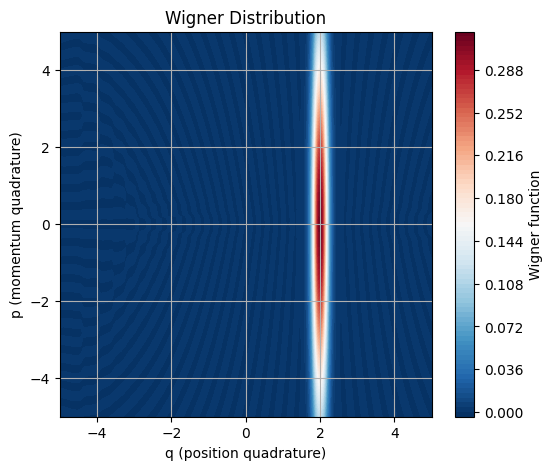

In [12]:
plot_wigner(system2)

In [ ]:
N = 10
q = position(N)

system3 = displace(N,2/np.sqrt(2))*squeeze(N,-7.5)*basis(N,0)

system1 = basis(2,0)
print("***Initial State***")
print(expect(sigmaz(), system1))
print(expect(q, system3))
lsb_test = tensor(system1,system3)
lsb_test_after = extractLSB(N)*lsb_test

system1_after = ptrace(lsb_test_after, 0)  # Partial trace over subsystem 2
print("***Final State***")
print(expect(sigmaz(), system1_after))

system2_after = ptrace(lsb_test_after, 1)  # Partial trace over subsystem 1
print(expect(q, system2_after))

***Initial State***
1.0
1.8851231030496352
***Final State***
0.3518240584421824
1.8851231030496323


## Aprroximation Bounds

In [21]:

x = 5                    
delta = 0.1             
Nfock = 10              
b = 0                      

a = destroy(Nfock)
q = (a + a.dag()) / np.sqrt(2)
p = -1j * (a - a.dag()) / np.sqrt(2)

s = squeeze(Nfock, -np.log(delta))     
d = displace(Nfock, 1/np.sqrt(2) * x)             
chi = d * s * basis(Nfock, 0)      

q0 = basis(2, 0)
q1 = basis(2, 1)
qb = basis(2, b)

psi0 = tensor(chi, qb)

H = hadamard()
I_m = qeye(Nfock)
H_full = tensor(I_m, H)
psi1 = H_full * psi0

proj1 = q1 * q1.dag()
proj0 = q0 * q0.dag()

U_cphase = tensor((qeye(Nfock)), proj0) + tensor((1j*q * np.pi).expm(), proj1)
psi2 = U_cphase * psi1

psi3 = (H_full * psi2).unit()

P0 = tensor(qeye(Nfock), q0 * q0.dag())
P1 = tensor(qeye(Nfock), q1 * q1.dag())

p0 = expect(P0, psi3)
p1 = expect(P1, psi3)

print(f"Input x = {x}, LSB(x) = {x % 2}, initial qubit b = {b}")
print(f"Output probabilities: P(qubit=0) = {p0:.4f}, P(qubit=1) = {p1:.4f}")

Input x = 5, LSB(x) = 1, initial qubit b = 0
Output probabilities: P(qubit=0) = 0.3915, P(qubit=1) = 0.6085


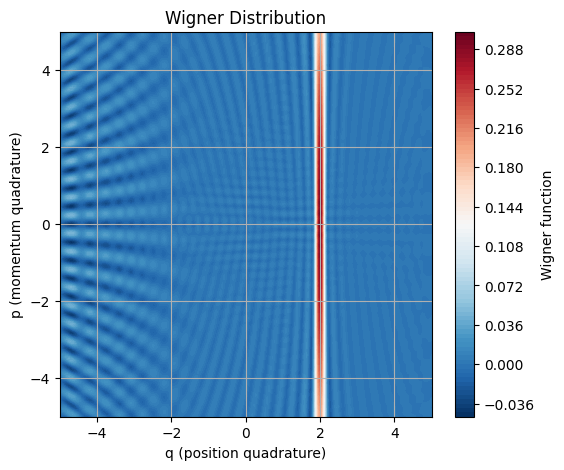

In [15]:
plot_wigner(chi)

In [16]:
def squeezing_mode(mode_index, factor, cutoff, num_modes):
    op = squeeze(cutoff, np.log(factor))
    ops = [qeye(cutoff) for _ in range(num_modes)]
    ops[mode_index] = op
    return tensor(*ops)

def extract_LSB(mode_index, cutoff, num_modes):
    had = hadamard()
    X0 = tensor(had, *[qeye(cutoff) for _ in range(num_modes)])

    proj_0 = basis(2, 0) * basis(2, 0).dag()
    proj_1 = basis(2, 1) * basis(2, 1).dag()
    expi_pi_x = (1j * np.pi * position(cutoff)).expm()

    ctrl = [qeye(cutoff) for _ in range(num_modes)]
    ctrl[mode_index] = expi_pi_x
    ctrl_op = tensor(proj_0, *[qeye(cutoff) for _ in range(num_modes)]) + tensor(proj_1, *ctrl)
    return X0 * ctrl_op * X0

def ctrl_shift(mode_index, cutoff, num_modes, sign=+1):
    exp_pm_ip = (-1j * position(cutoff)).expm() if sign > 0 else (1j * position(cutoff)).expm()
    ctrl = [qeye(cutoff) for _ in range(num_modes)]
    ctrl[mode_index] = exp_pm_ip
    return (
        tensor(basis(2, 0) * basis(2, 0).dag(), *[qeye(cutoff) for _ in range(num_modes)]) +
        tensor(basis(2, 1) * basis(2, 1).dag(), *ctrl)
    )

def ctrl_mult_alpha(mode_index, alpha, cutoff, num_modes):
    mult_op = (np.log(alpha) * position(cutoff)).expm()
    ctrl = [qeye(cutoff) for _ in range(num_modes)]
    ctrl[mode_index] = mult_op
    return (
        tensor(basis(2, 0) * basis(2, 0).dag(), *[qeye(cutoff) for _ in range(num_modes)]) +
        tensor(basis(2, 1) * basis(2, 1).dag(), *ctrl)
    )

def V_alpha_steps(alpha, cutoff):
    num_modes = 3  # A, B, C
    qubit_dim = 2
    steps = []

    steps.append(tensor(qeye(qubit_dim), squeezing_mode(2, 2, cutoff, num_modes)))  # M_2 on C
    steps.append(extract_LSB(0, cutoff, num_modes))  # extract LSB from A
    steps.append(ctrl_shift(0, cutoff, num_modes, sign=+1))  # ctrl shift on A
    steps.append(ctrl_mult_alpha(1, alpha, cutoff, num_modes))  # ctrl mult on B
    steps.append(ctrl_shift(2, cutoff, num_modes, sign=-1))  # ctrl shift on C
    steps.append(extract_LSB(2, cutoff, num_modes))  # extract LSB from C
    steps.append(tensor(qeye(qubit_dim), squeezing_mode(0, 0.5, cutoff, num_modes)))  # M_{1/2} on A

    return steps

# --- Initial state ---
def squeezed_displaced_state(x, r, cutoff):
    return displace(cutoff, x) * squeeze(cutoff, -np.log(r)) * basis(cutoff, 0)

def initial_state_squeezed(x=2, y=3, z=4, r=1.0, cutoff=10):
    a = squeezed_displaced_state(x, r, cutoff)
    b = squeezed_displaced_state(y, r, cutoff)
    c = squeezed_displaced_state(z, r, cutoff)
    q = basis(2, 0)
    return tensor(q, a, b, c)

# --- Visualization function ---
def plot_marginal(state, cutoff, step_name, mode_names=["A", "B", "C"], xvec=np.linspace(-10, 10, 500)):
    fig, axs = plt.subplots(1, 3, figsize=(15, 3))
    for i, label in enumerate(mode_names):
        reduced = state.ptrace(i + 1)  # skip qubit
        pos_op = position(cutoff)
        prob_density = np.array([
            expect(basis(cutoff, 0).dag() * reduced * basis(cutoff, 0), basis(cutoff, 0).x(x)**2)
            for x in xvec
        ])
        prob_density /= np.trapz(prob_density, xvec)  # normalize so area under curve is 1
        axs[i].plot(xvec, prob_density)
        axs[i].set_title(f"Mode {label}")
        axs[i].set_xlabel("x (position)")
        axs[i].set_ylabel("P(x)")
        axs[i].set_ylim(bottom=0)
    fig.suptitle(step_name)
    plt.tight_layout()
    plt.show()

# --- Run test and visualize ---
def run_V_alpha_test(alpha=2, x=2, y=3, z=4,r=1.0, cutoff=10):
    state = initial_state_squeezed(x, y, z,r, cutoff)
    # plot_marginal(state, cutoff, "Initial State")

    steps = V_alpha_steps(alpha, cutoff)
    names = [
        "Step 1: Squeeze C",
        "Step 2: Extract LSB from A",
        "Step 3: Ctrl Shift A",
        "Step 4: Ctrl Mult B",
        "Step 5: Ctrl Shift C",
        "Step 6: Extract LSB from C",
        "Step 7: Squeeze A (1/2)"
    ]

    for i, (gate, label) in enumerate(zip(steps, names)):
        state = gate * state
        # plot_marginal(state, cutoff, label)

    return state

# --- Run it ---
final_state = run_V_alpha_test(alpha=2, x=2, y=3, z=4,r=0.2, cutoff=10)